# 1. Build and validate a hierarchical Bayesian MMM

**Question:** How can a fixed advertising budget be allocated across five channels under uncertainty?

This is an independent portfolio project on Google Meridian's **simulated** example data. The model is a custom NumPyro implementation, not Meridian itself. This notebook reads saved, executed-model results; it does not silently refit MCMC. Executable modeling code lives in `../src/fit_mcmc.py`; reproduction commands are in the README.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
if not (ROOT/'reports').is_dir(): ROOT=ROOT.parent
assert (ROOT/'reports/data_audit.json').is_file(), 'Run from the repository root or notebooks directory.'
audit=json.loads((ROOT/'reports/data_audit.json').read_text())
print({k:audit[k] for k in ['rows','geos','weeks','first_week','last_week']})
print(audit['source_type'])

{'rows': 6240, 'geos': 40, 'weeks': 156, 'first_week': '2021-01-25', 'last_week': '2024-01-15'}
official simulated example, not real advertiser data


## Model and identification assumptions

Each observation is one region-week. Conversions are modeled on a scaled per-capita basis. Advertising enters through normalized 12-lag geometric adstock and a fixed-slope Hill curve:

$$y^*_{g,t}\sim N(\mu_{g,t},\sigma^2),\qquad
\mu_{g,t}=\alpha_g+B_t\delta+Z_{g,t}\gamma+\sum_m\beta_{g,m}\frac{a_{g,t,m}}{a_{g,t,m}+K_m}.$$

Regional intercepts and log media coefficients partially pool through hierarchical priors. Decay and saturation parameters are shared across regions within each channel. Time terms include a linear trend and annual seasonality; covariates include competitor sales, sentiment, promotion and organic exposure.

Paid effects are constrained positive. Covariates are assumed appropriate for adjustment; sentiment timing and possible mediation remain unresolved. This is a conditional causal interpretation, not proof of causal identification. The Gaussian outcome permits negative draws. Exact priors and normalization are documented in `../docs/model_specification.md`.

The initial 130 weeks are used for training, with 12 warmup-history weeks excluded from the likelihood. The last 26 weeks are held out. Training-only scales are preserved in evaluation.

chains                 4.000000
warmup_per_chain    1000.000000
draws_per_chain     1000.000000
divergences            0.000000
max_rhat               1.005653
min_bulk_ess         851.282925
min_tail_ess        1211.715575
Name: Sampler diagnostics, dtype: float64

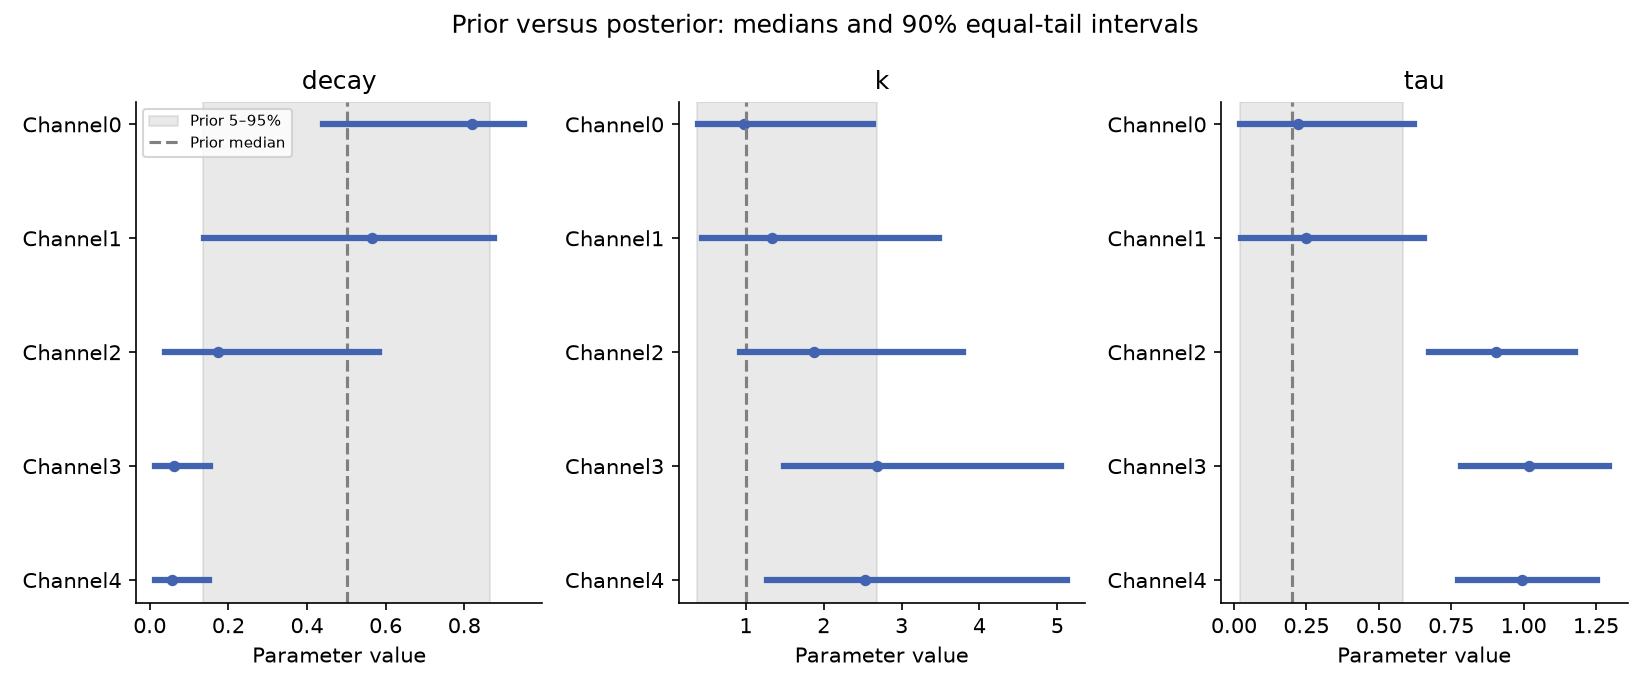

In [2]:
d=json.loads((ROOT/'reports/mcmc/diagnostics.json').read_text())
display(pd.Series({k:d[k] for k in ['chains','warmup_per_chain','draws_per_chain','divergences','max_rhat','min_bulk_ess','min_tail_ess']},name='Sampler diagnostics'))
display(Image(filename=str(ROOT/'reports/mcmc/prior_vs_posterior.png')))

## Posterior checks and honest temporal validation

Good sampler diagnostics mean the posterior has been sampled adequately; they do not validate causal assumptions. The holdout supplies actual contemporaneous inputs, so this is conditional prediction rather than an unconditional future forecast.

The primary metric is RMSE in scaled per-capita units, weighting region-weeks equally. Benchmarks are each region's historical mean and the same region's observation 52 weeks earlier.

RMSE improvement versus regional mean: 7.9%


,rmse_scaled,mae_scaled,wape
MMM,0.297499,0.237732,0.226936
Regional mean,0.323078,0.253485,0.242366
Seasonal naive,0.439540,0.346404,0.336263


,nominal,coverage,mean_width_scaled
0,0.50,0.484615,0.388477
1,0.80,0.778846,0.738043
2,0.90,0.881731,0.947208
3,0.95,0.937500,1.128277


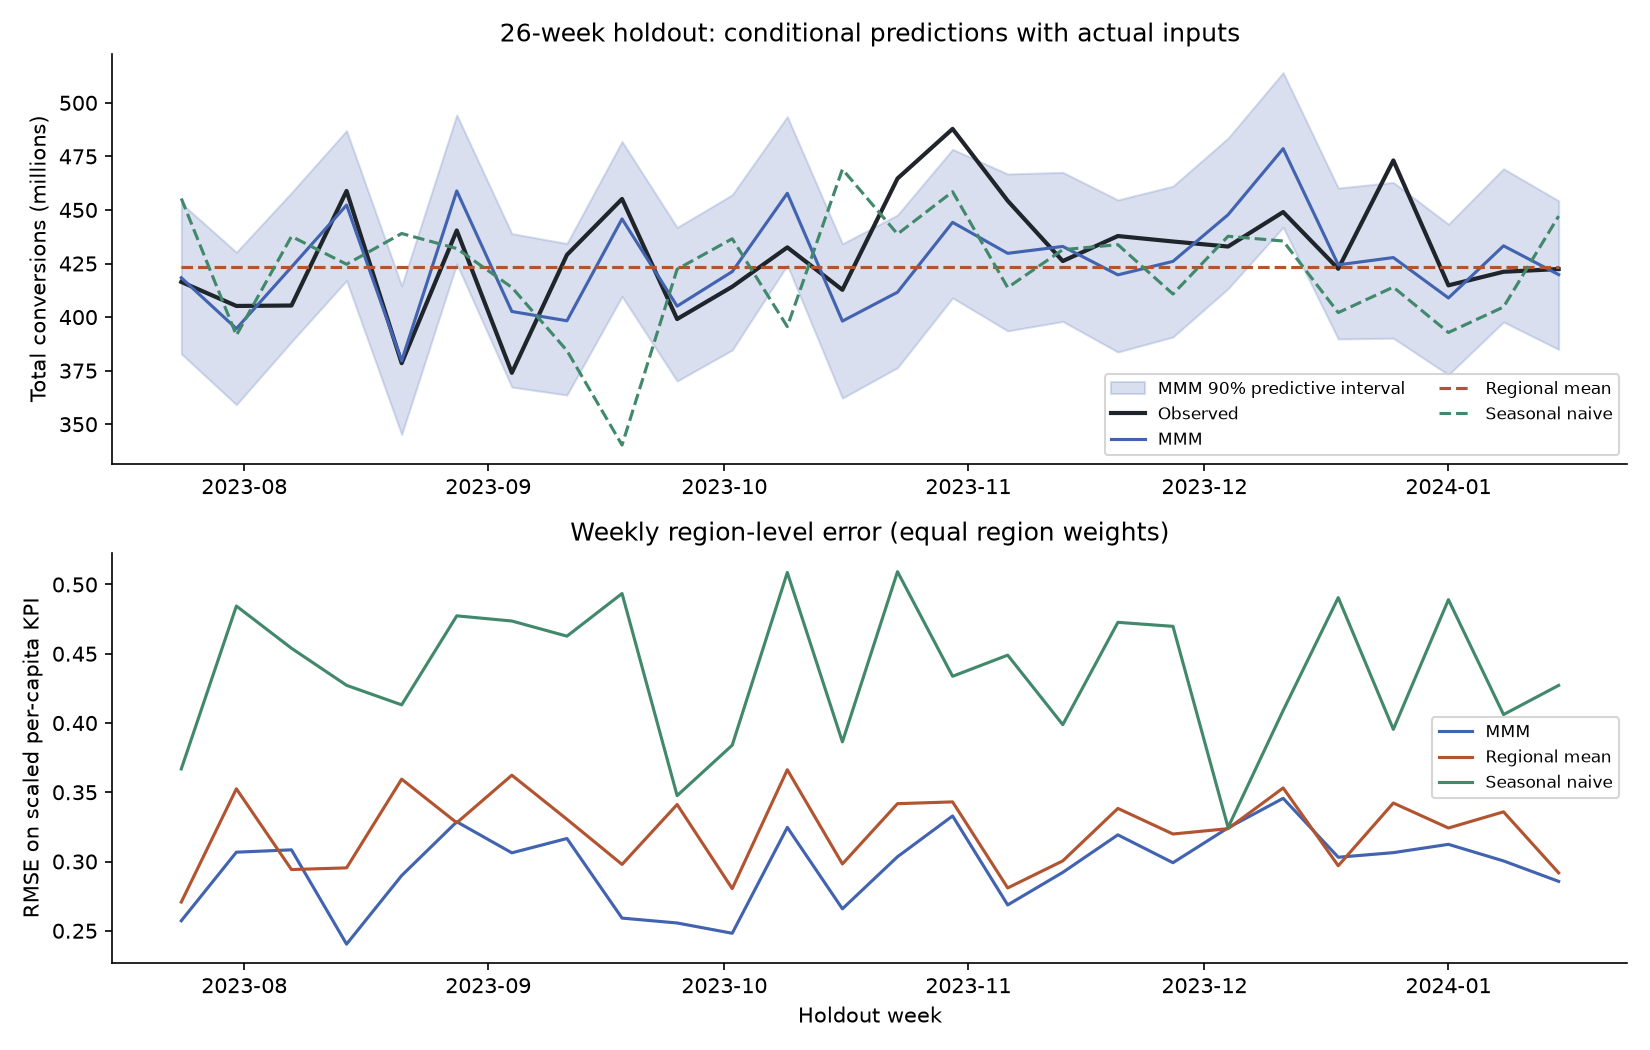

In [3]:
h=json.loads((ROOT/'reports/holdout/metrics.json').read_text())
display(pd.DataFrame(h['metrics']).T[['rmse_scaled','mae_scaled','wape']])
print('RMSE improvement versus regional mean:',f"{1-h['metrics']['MMM']['rmse_scaled']/h['metrics']['Regional mean']['rmse_scaled']:.1%}")
display(pd.DataFrame(h['coverage']))
display(Image(filename=str(ROOT/'reports/holdout/holdout_predictions.png')))

## What this establishes

Holdout RMSE improves 7.9% over the regional-mean baseline; 90% predictive intervals cover 88.2% of observations. The model beats that baseline in 27 of 40 regions, not all regions. Prediction checks support proceeding with conditional scenario analysis while retaining limitations.

Next: `02_channel_effects_and_budget.ipynb` translates the joint posterior into effects and one constrained budget decision.